# Comparación NSRDB vs ERA5 — Tamaulipas, 43 nodos

Tres fuentes sobre los **mismos 43 puntos** (uno por cabecera municipal), hora a hora:

| fuente | resolución | qué es |
|---|---|---|
| **NSRDB** PSM v4 | 0.04° (~4 km) | satélite GOES + meteorología de MERRA-2 |
| **ERA5-Land** | 0.1° (~9 km) | reanálisis, **solo tierra** |
| **ERA5-single** | 0.25° (~31 km) | reanálisis |

ERA5 cubre **2020–2025**; el NSRDB de este repo llega a **2024**. Las gráficas lo
avisan en el pie cuando el tramo pedido se sale.

La documentación completa de la función está en [`README.md`](README.md).

## 1. Preparación

In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

# El notebook vive dos niveles por debajo de la raíz del repo; sin esto los
# `import copernicus...` no encuentran el paquete.
RAIZ = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if RAIZ not in sys.path:
    sys.path.insert(0, RAIZ)

from copernicus.graficas import (comparar_series, cargar,
                                 catalogo_lugares, resolver_lugares, COLOR)

pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

### El catálogo de lugares

`comparar_series` acepta el nombre del municipio (sin importar acentos ni
mayúsculas) o el `nodo_id`. Estos son los 43 disponibles:

In [2]:
cat = catalogo_lugares()
print(f"{len(cat)} nodos, de {cat.msnm.min():.0f} a {cat.msnm.max():.0f} m de altitud")
cat.head(10)

43 nodos, de 6 a 2140 m de altitud


,nodo_id,cve_mun,municipio,latitude,longitude,msnm
0,2120,001,Abasolo,24.05,-98.38,55.0
1,637,002,Aldama,22.93,-98.06,142.0
2,25,003,Altamira,22.41,-97.94,6.0
3,154,004,Antiguo Morelos,22.57,-99.10,193.0
4,3094,005,Burgos,24.93,-98.82,198.0
5,1343,006,Bustamante,23.45,-99.78,2140.0
6,4118,007,Camargo,26.33,-98.82,49.0
7,1747,008,Casas,23.73,-98.74,157.0
8,5,009,Ciudad Madero,22.29,-97.82,6.0
9,2953,010,Cruillas,24.77,-98.54,213.0


In [3]:
# El nombre se resuelve de forma laxa: parcial, sin acentos y sin distinguir
# mayúsculas. Un nombre que no existe falla AQUÍ, con la lista delante.
resolver_lugares(["victoria", "TAMPICO", "guemez", 3978])

,nodo_id,cve_mun,municipio,latitude,longitude,msnm
0,1737,041,Victoria,23.73,-99.14,331.0
1,1,038,Tampico,22.25,-97.86,21.0
2,1969,013,Güémez,23.93,-99.02,175.0
3,3978,032,Reynosa,26.05,-98.30,51.0


### Las variables

Cualquier variable del catálogo del NSRDB que ERA5 también traiga. Las seis
descargadas de ERA5 son `temperature`, `dew_point`, `relative_humidity`,
`pressure`, `wind_speed`, `wind_direction`, más `ghi` derivada de `ssrd`.

In [4]:
from urbano.clima import variables as V

COMPARABLES = ["ghi", "temperature", "dew_point", "relative_humidity",
               "pressure", "wind_speed", "wind_direction"]
V.tabla().query("variable in @COMPARABLES").reset_index(drop=True)

,variable,unidad,altura,tipo,descripcion
0,ghi,W/m²,superficie,continua,Irradiancia global horizontal
1,temperature,°C,2 m,continua,"Temperatura del aire a 2 m (MERRA-2 T2M, corre..."
2,dew_point,°C,2 m,continua,"Punto de rocío, derivado de T2M/QV2M/PS"
3,relative_humidity,%,2 m,continua,"Humedad relativa, derivada de T2M/QV2M/PS"
4,pressure,mbar,superficie,continua,"Presión en superficie (MERRA-2 PS, corregida p..."
5,wind_speed,m/s,2 m,continua,Velocidad del viento a 2 m (MERRA-2 U2M/V2M) —...
6,wind_direction,grados,2 m,circular,"Dirección del viento a 2 m (de dónde sopla, 0–..."


## 2. Lo mínimo

Solo la variable es obligatoria. Todo lo demás tiene valor por omisión y los
textos se autogeneran.

findfont: Failed to find font weight 600, now using 700.


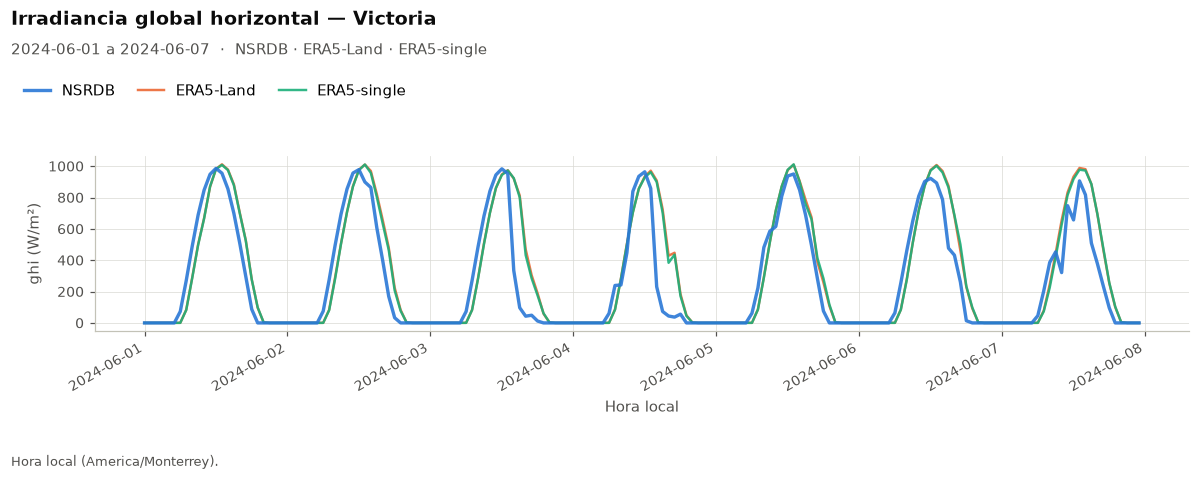

In [5]:
comparar_series("ghi", lugares="victoria", desde="2024-06-01", hasta="2024-06-07");

Se ve lo que se esperaba de estas fuentes: en días despejados las tres coinciden
casi exactamente, y las diferencias aparecen cuando hay nubes (el 4 y el 7 de
junio). Tiene sentido — a esta escala la irradiancia la manda la nubosidad, y
ahí el NSRDB parte de observación satelital mientras ERA5 la modela.

## 3. Filtros de tiempo

### `desde` / `hasta`

Inclusivos, en hora **local**. Un día suelto (`"2024-06-30"`) se entiende como el
día completo, no como su medianoche.

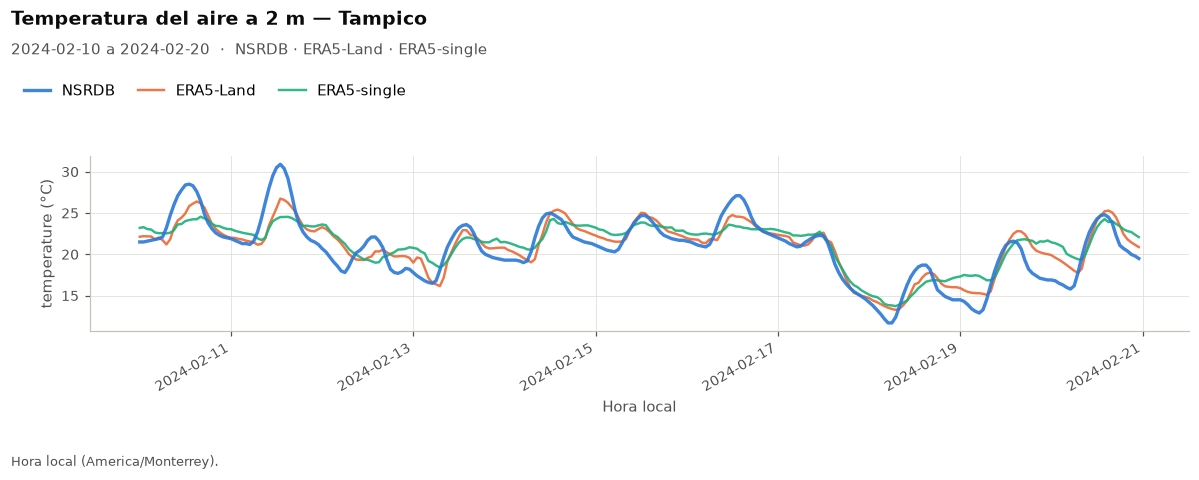

In [6]:
comparar_series("temperature", lugares="tampico",
                desde="2024-02-10", hasta="2024-02-20");

### `horas` — quedarse con parte del día

`(11, 17)` es un rango inclusivo; `[6, 12, 18]` son horas sueltas. Para la
irradiancia es el filtro más útil: promediar el GHI con las noches dentro diluye
justo lo que se quiere comparar.

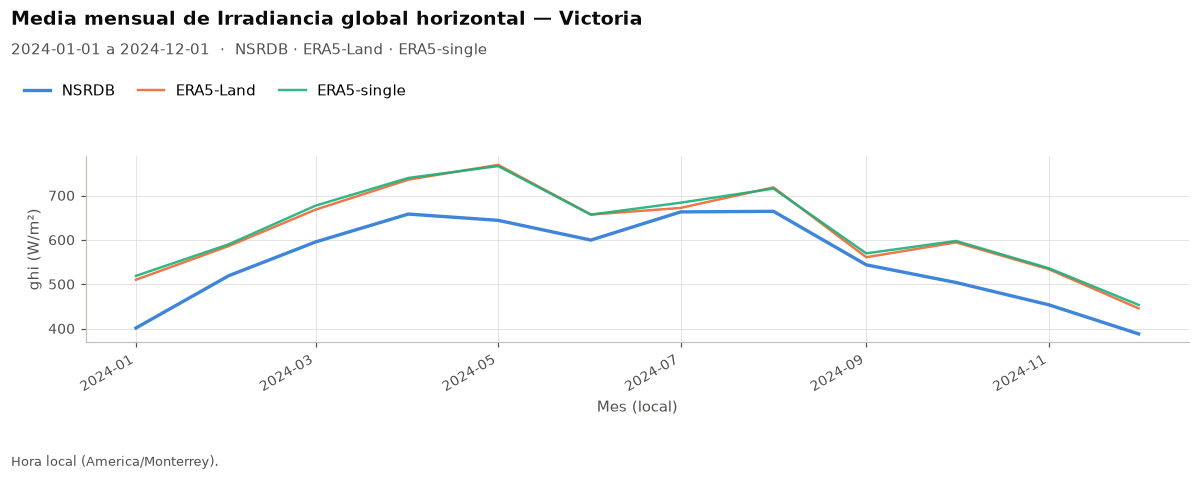

In [7]:
# Media mensual de GHI solo en horas de sol
comparar_series("ghi", lugares="victoria", horas=(11, 17),
                desde="2024-01-01", hasta="2024-12-31", frecuencia="mes");

### `meses` — quedarse con una temporada

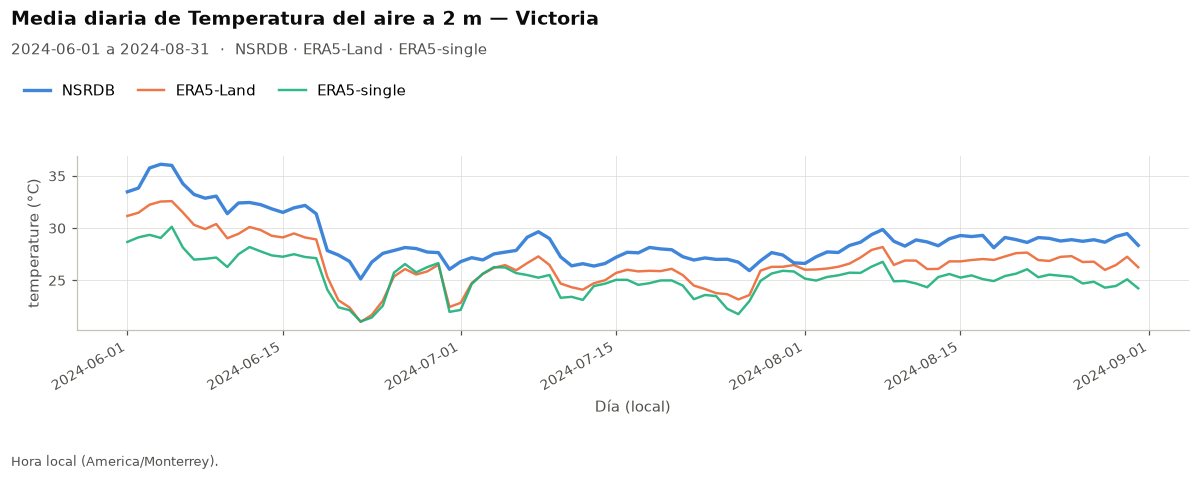

In [8]:
# Solo el verano, día a día
comparar_series("temperature", lugares="victoria", meses=[6, 7, 8],
                desde="2024-01-01", hasta="2024-12-31", frecuencia="dia");

## 4. Uno o varios lugares

Con **un** lugar sale un panel. Con **varios**, un panel por lugar
(*small multiples*): el color sigue siendo el de la fuente, así que las tres
líneas significan lo mismo en todos los paneles.

findfont: Failed to find font weight 600, now using 700.


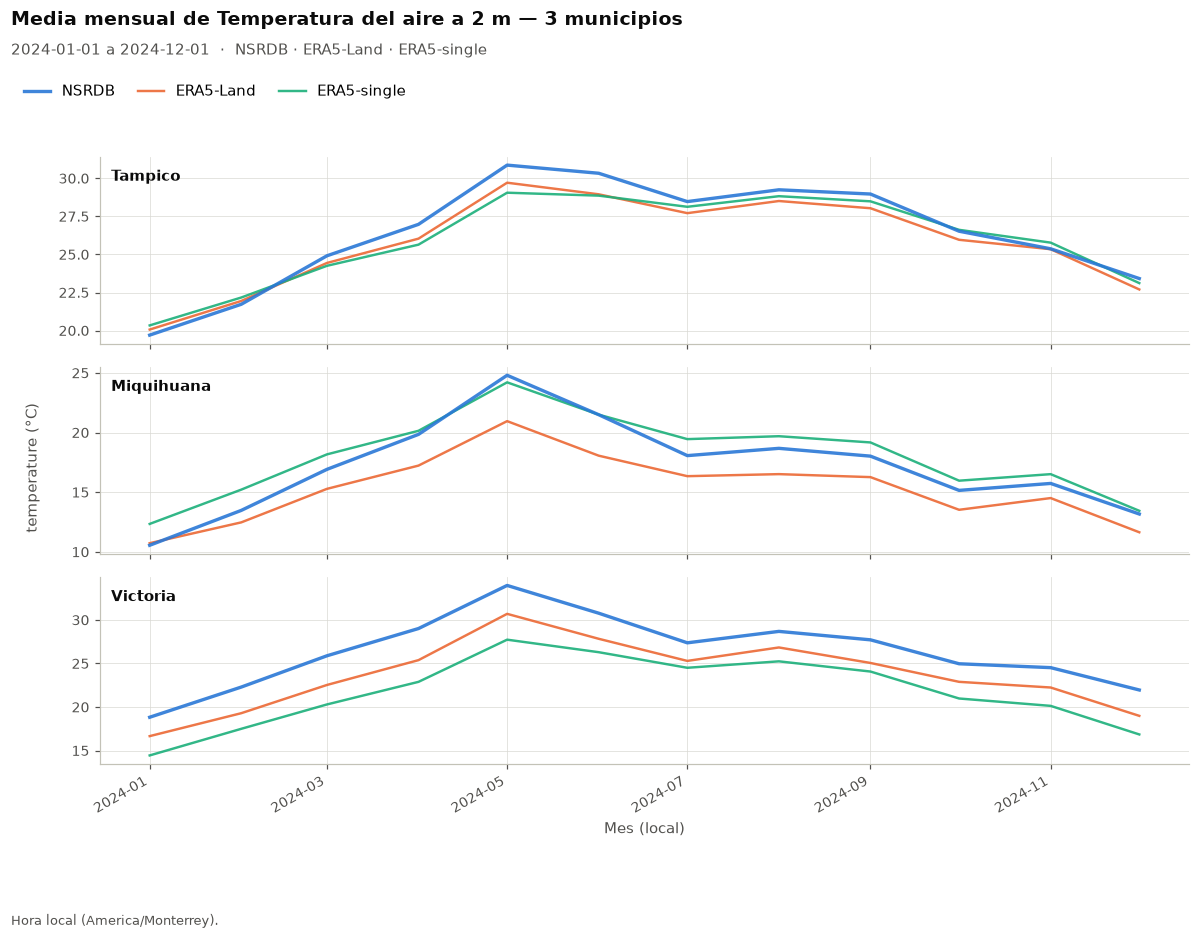

In [9]:
comparar_series("temperature", lugares=["Victoria", "Tampico", "Miquihuana"],
                desde="2024-01-01", hasta="2024-12-31", frecuencia="mes");

Miquihuana (1946 m) es el caso interesante: **ERA5-Land se queda 3-4 °C por
debajo** todo el año mientras ERA5-single acierta. No es que la malla fina sea
peor — es que la celda de 0.1° que le toca promedia una altitud distinta a la del
nodo, y a −6.5 °C/km eso solo explica el sesgo. En Tampico, a nivel del mar, las
tres se pegan.

Con `facetas=False` se encima todo en un eje. Las fuentes mantienen su color y
los lugares se distinguen por el estilo de línea — nunca por otro color, para que
añadir un municipio no repinte los demás. Es legible con dos lugares; con cinco
ya no.

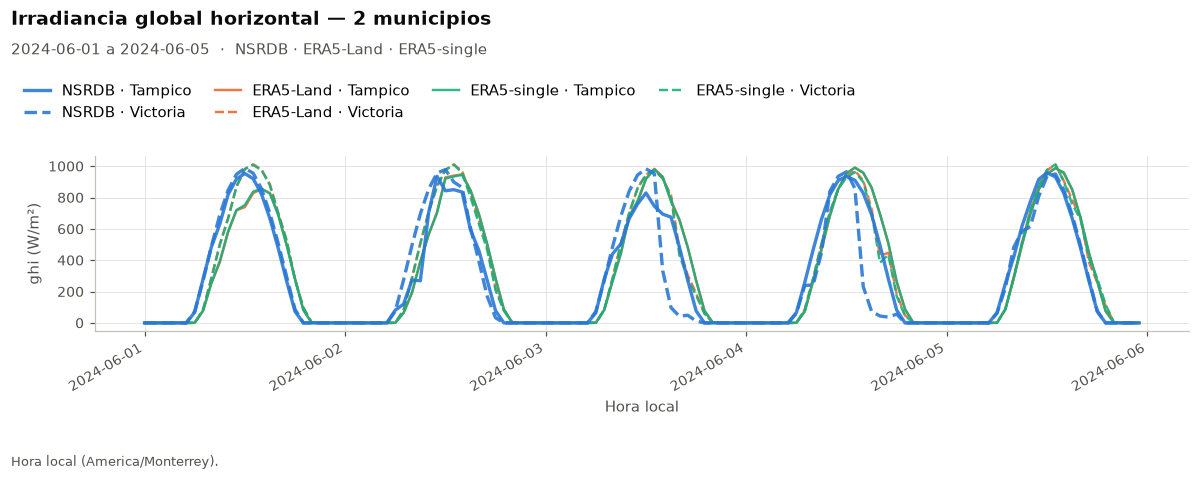

In [10]:
comparar_series("ghi", lugares=["Victoria", "Tampico"],
                desde="2024-06-01", hasta="2024-06-05", facetas=False);

## 5. Frecuencia y agregación

`frecuencia` es `"hora"` (la serie cruda), `"dia"` o `"mes"`; `agregacion` es
`"media"`, `"max"`, `"min"` o `"suma"`.

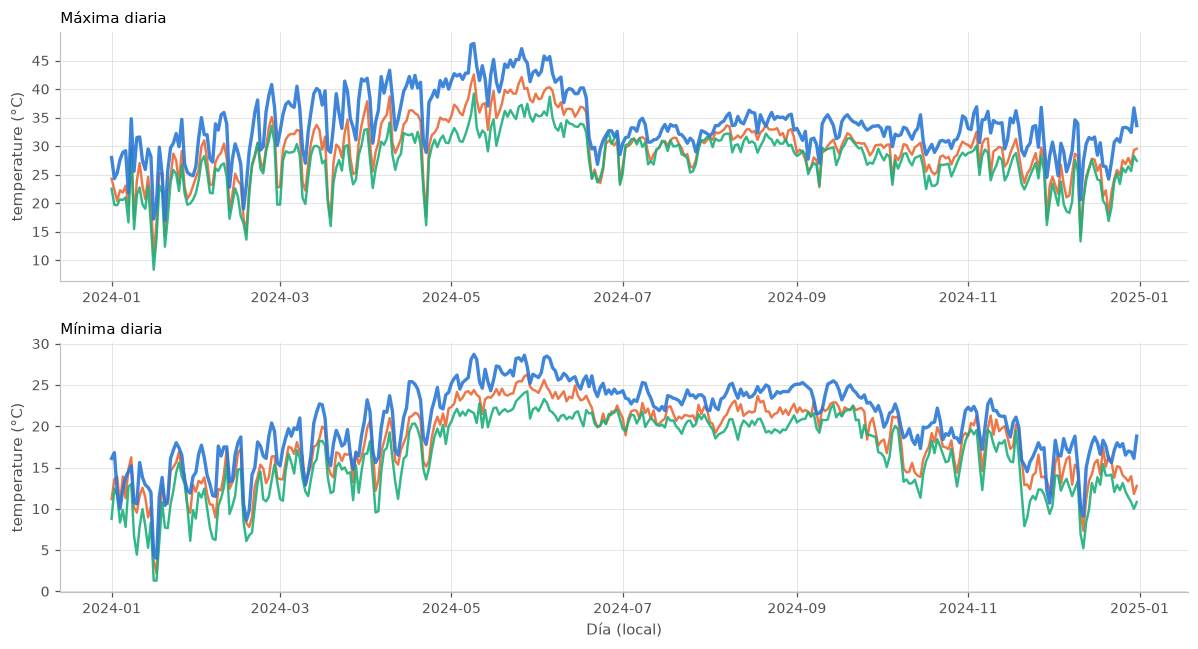

In [11]:
fig, ejes = plt.subplots(2, 1, figsize=(11, 6))
comparar_series("temperature", lugares="victoria", desde="2024-01-01",
                hasta="2024-12-31", frecuencia="dia", agregacion="max",
                ax=ejes[0], etiqueta_x="")
comparar_series("temperature", lugares="victoria", desde="2024-01-01",
                hasta="2024-12-31", frecuencia="dia", agregacion="min",
                ax=ejes[1])
ejes[0].set_title("Máxima diaria", fontsize=10, loc="left")
ejes[1].set_title("Mínima diaria", fontsize=10, loc="left")
fig.tight_layout();

Las mínimas se separan más que las máximas: el enfriamiento nocturno depende del
terreno local, que una celda de 9 o 31 km promedia.

## 6. Elegir fuentes

`fuentes` acepta una o varias. Con una sola, la leyenda desaparece — el título ya
la nombra.

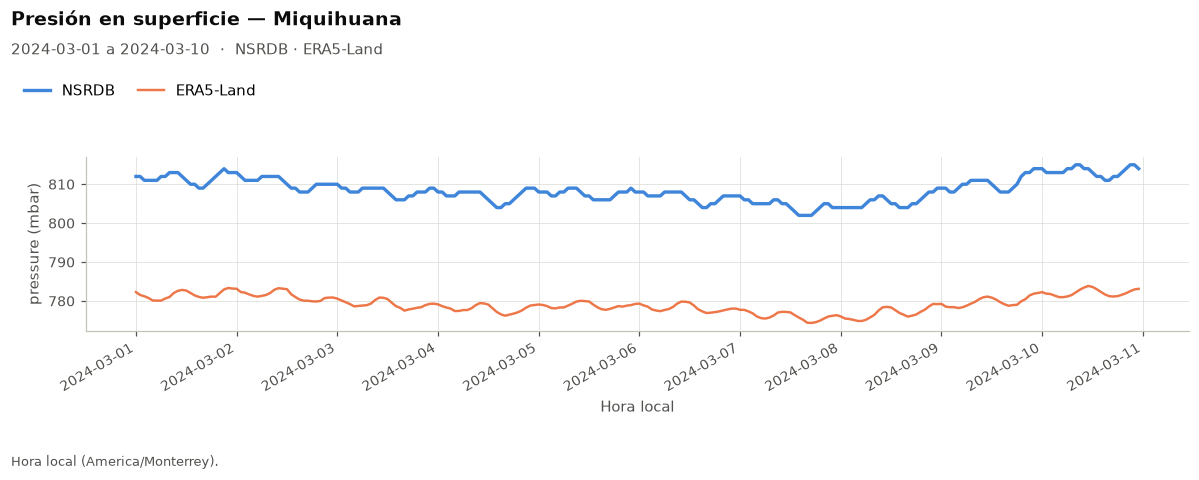

In [12]:
comparar_series("pressure", lugares="miquihuana", desde="2024-03-01",
                hasta="2024-03-10", fuentes=["NSRDB", "ERA5-Land"]);

## 7. Los textos

`titulo`, `subtitulo`, `etiqueta_x`, `etiqueta_y` y `nota`:

- **omitidos** (`None`) → se autogeneran;
- **una cadena** → se usa tal cual;
- **`""`** → se quitan, sin dejar hueco.

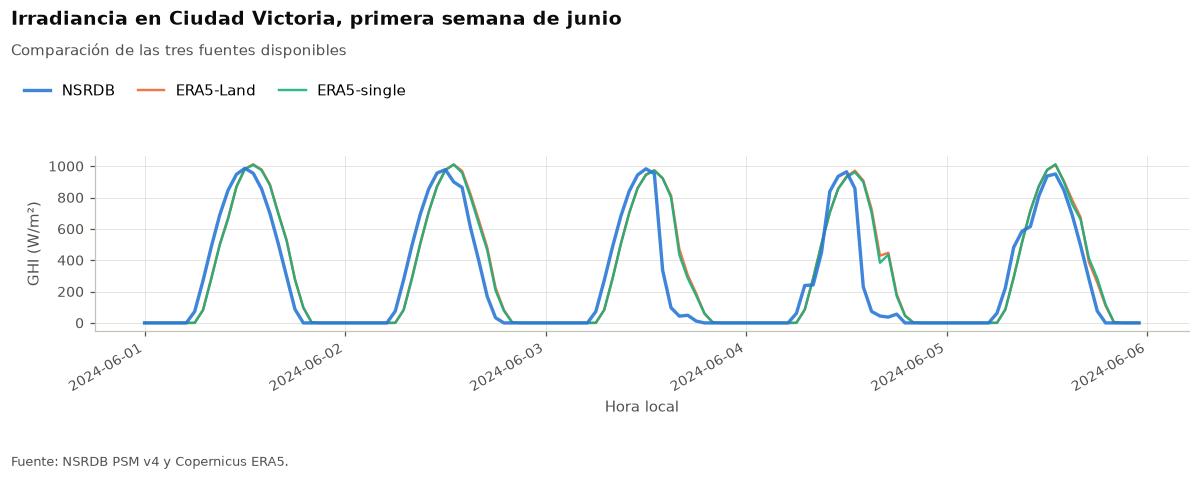

In [13]:
comparar_series("ghi", lugares="victoria", desde="2024-06-01", hasta="2024-06-05",
                titulo="Irradiancia en Ciudad Victoria, primera semana de junio",
                subtitulo="Comparación de las tres fuentes disponibles",
                etiqueta_y="GHI (W/m²)",
                nota="Fuente: NSRDB PSM v4 y Copernicus ERA5.");

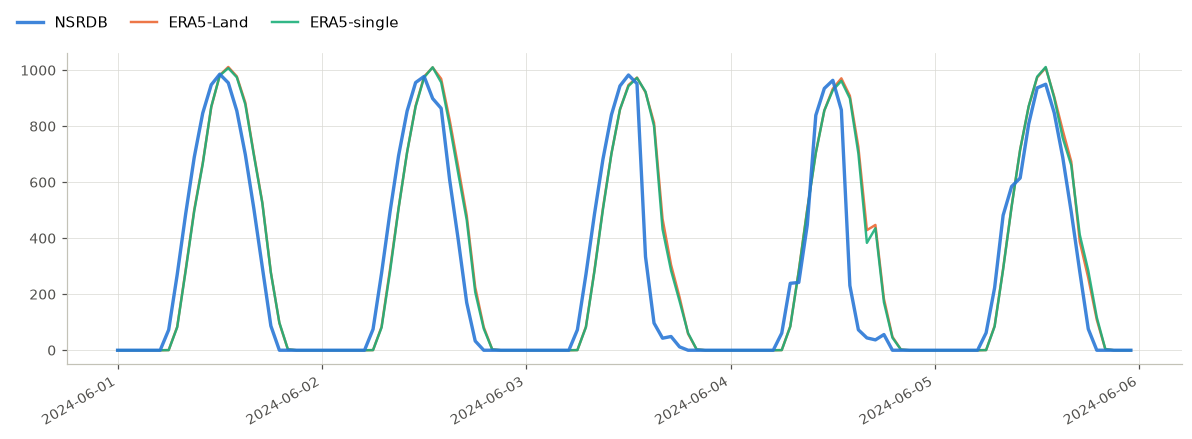

In [14]:
# Sin ningún texto: para incrustar en otro documento que ya lleva su pie
comparar_series("ghi", lugares="victoria", desde="2024-06-01", hasta="2024-06-05",
                titulo="", subtitulo="", nota="", etiqueta_x="", etiqueta_y="");

## 8. Reutilizar los datos

Cargar el NSRDB tarda. `cargar()` devuelve la tabla larga y `comparar_series`
la acepta en `datos=`, de modo que varias vistas del mismo periodo se pagan una
sola vez. Los filtros se siguen aplicando sobre ella.

In [15]:
d = cargar("ghi", lugares=["Victoria", "Tampico", "Reynosa"],
           desde="2024-01-01", hasta="2024-12-31")
print(f"{len(d):,} filas")
d.head(3)

79,038 filas


,nodo_id,municipio,datetime_utc,datetime_local,valor,fuente,variable
0,1,Tampico,2024-01-01 06:00:00+00:00,2024-01-01 00:00:00,0.0,ERA5-Land,ghi
1,1,Tampico,2024-01-01 07:00:00+00:00,2024-01-01 01:00:00,0.0,ERA5-Land,ghi
2,1,Tampico,2024-01-01 08:00:00+00:00,2024-01-01 02:00:00,0.0,ERA5-Land,ghi


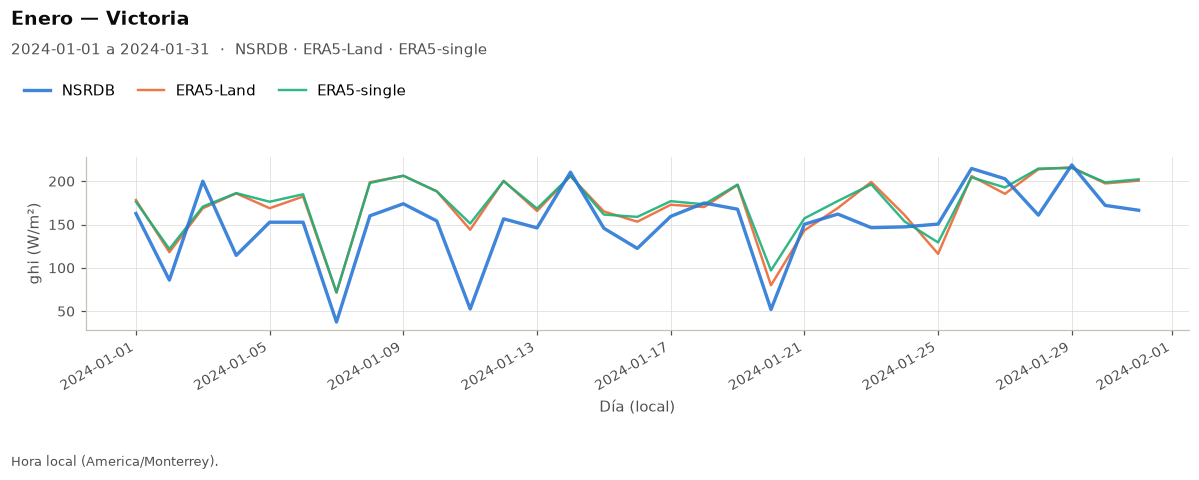

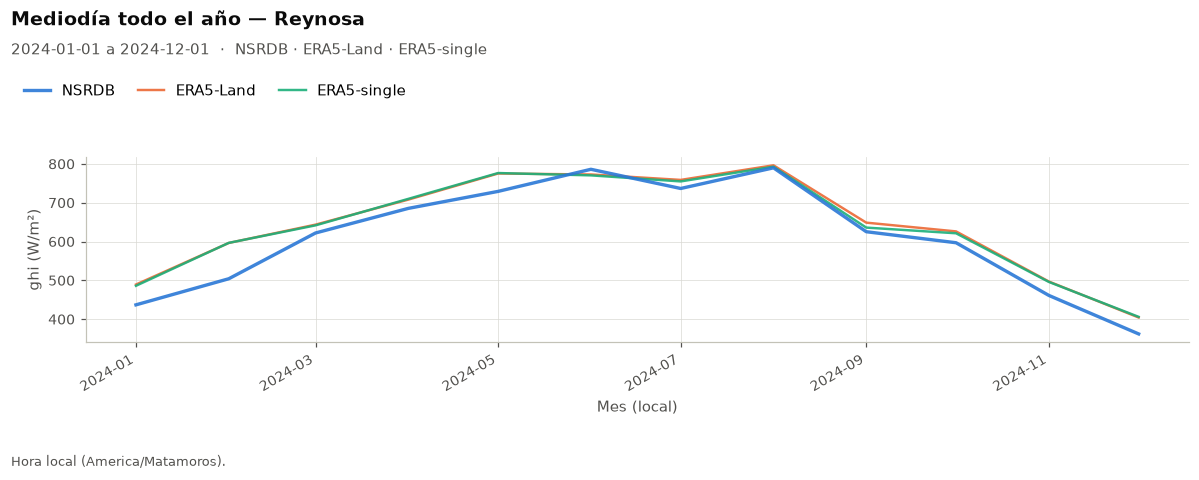

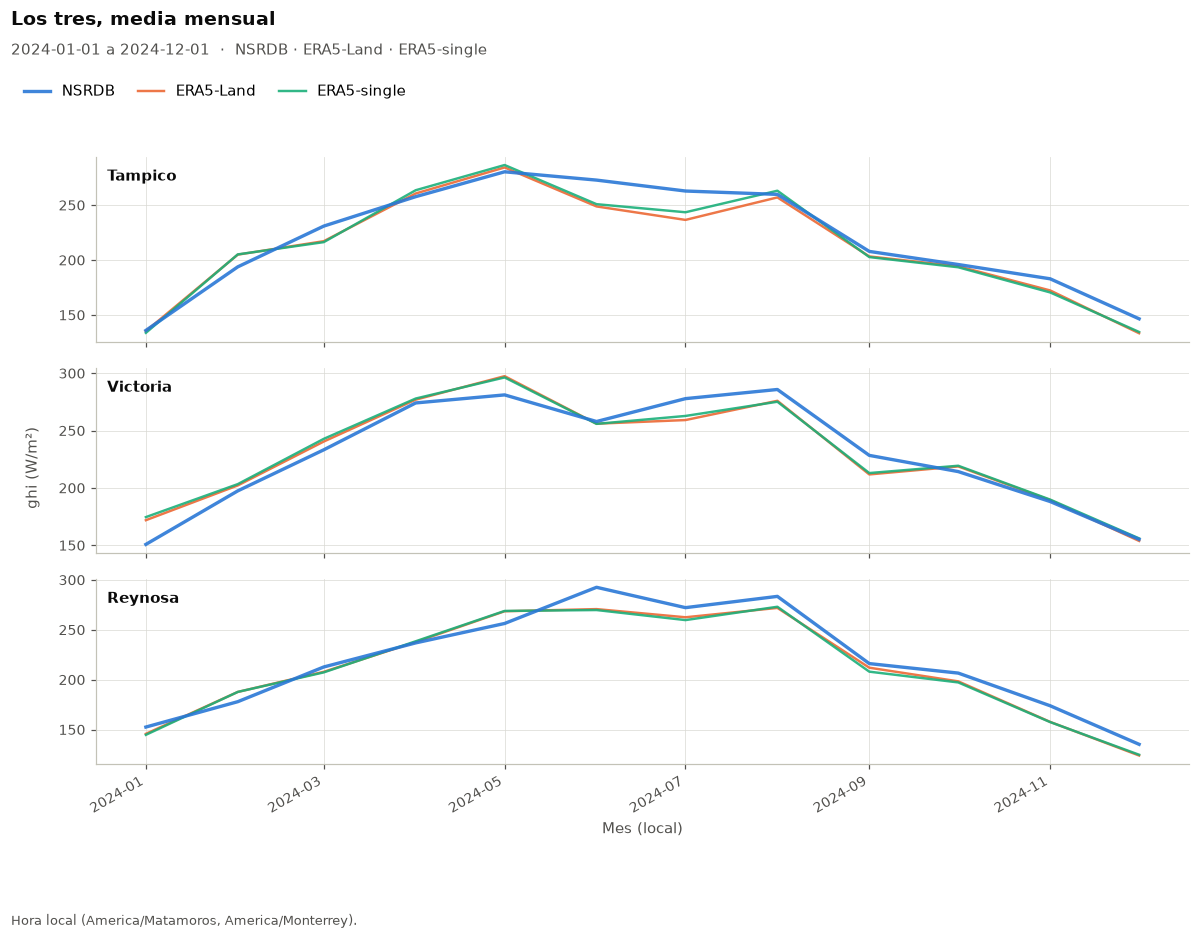

In [16]:
# Tres recortes distintos, sin releer nada
comparar_series(datos=d, lugares="Victoria", meses=[1], frecuencia="dia",
                titulo="Enero — Victoria")
comparar_series(datos=d, lugares="Reynosa", horas=(12, 16), frecuencia="mes",
                titulo="Mediodía todo el año — Reynosa")
comparar_series(datos=d, frecuencia="mes", titulo="Los tres, media mensual");

## 9. Hora local vs UTC

Por omisión el eje va en **hora local**, y `horas=` filtra sobre ese mismo reloj.
Con `tz="utc"` ambas cosas cambian a la vez.

Ojo con un detalle del estado: los 10 municipios de la **franja fronteriza**
(Reynosa, Matamoros, Nuevo Laredo…) mantuvieron el horario estacional cuando el
resto de Tamaulipas lo dejó en 2022, así que en verano no van a la misma hora
local que Victoria. La conversión se hace por municipio y el pie dice qué zonas
hay en juego.

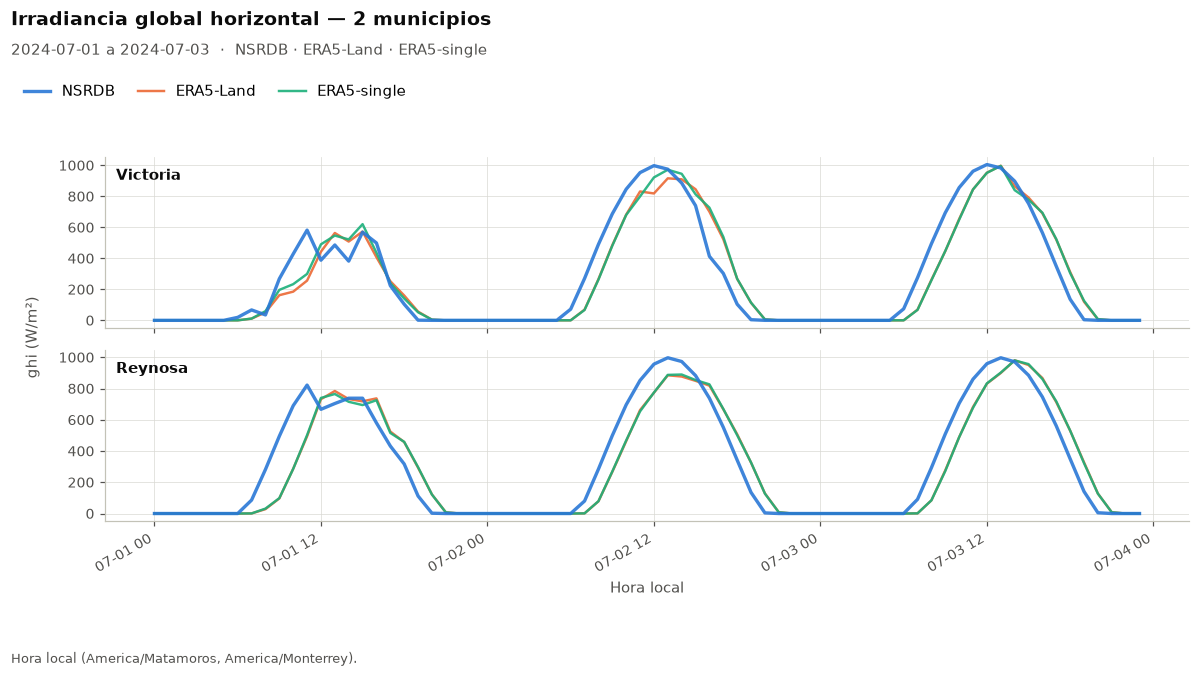

In [17]:
comparar_series("ghi", lugares=["Reynosa", "Victoria"],
                desde="2024-07-01", hasta="2024-07-03");

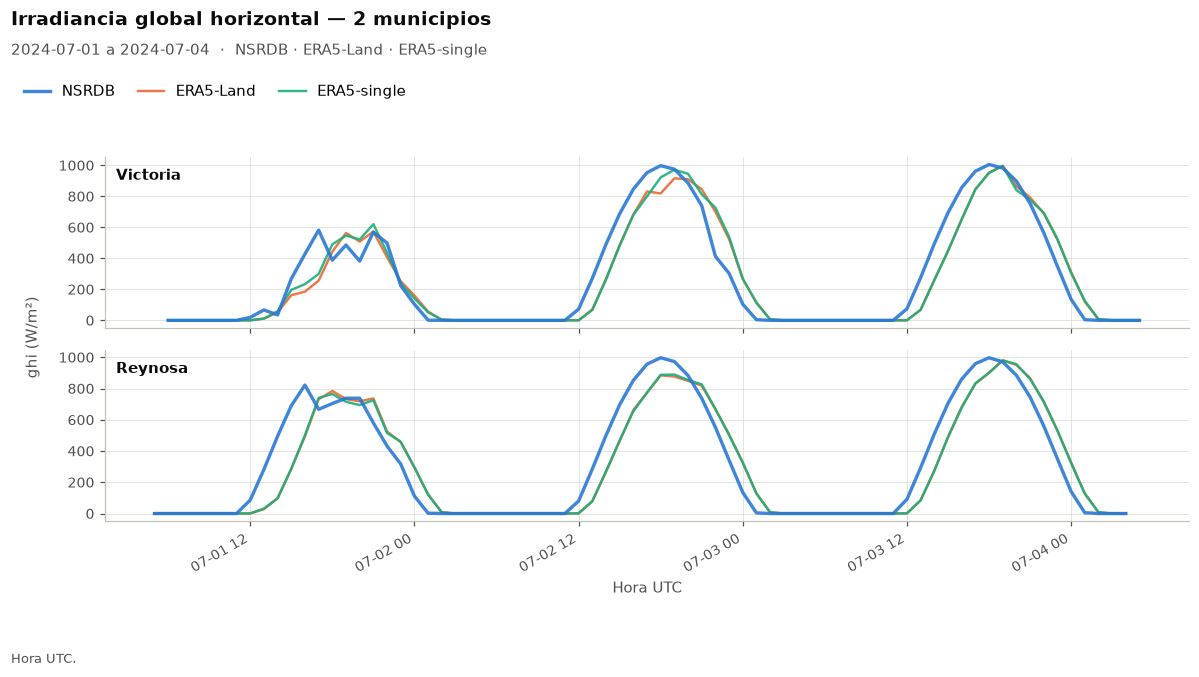

In [18]:
comparar_series("ghi", lugares=["Reynosa", "Victoria"],
                desde="2024-07-01", hasta="2024-07-03", tz="utc");

## 10. Los casos que hay que saber leer

### ERA5 llega a 2025; el NSRDB no

No es un error: se dibuja lo que hay y el aviso lo dice.

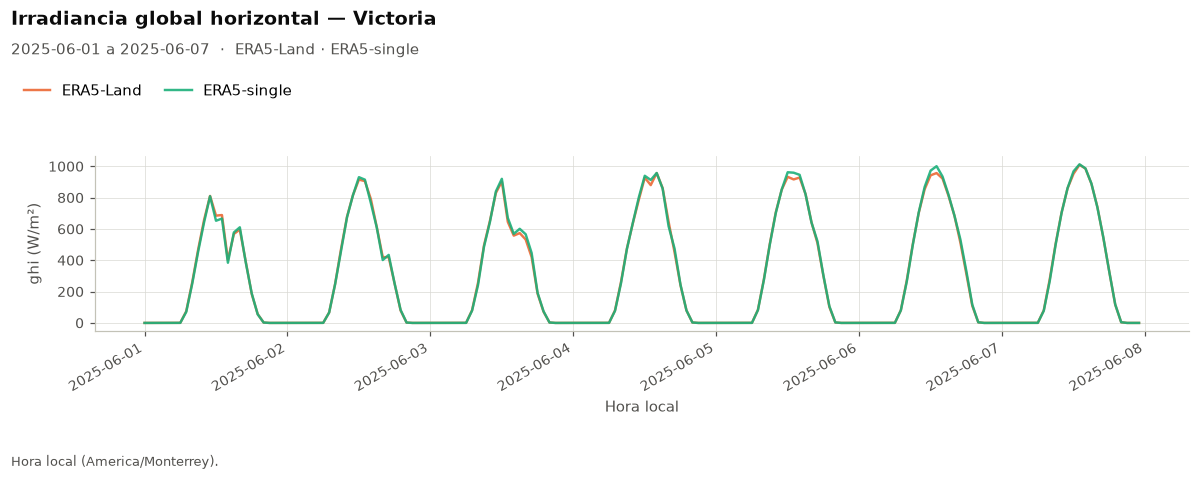

In [19]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")      # el aviso ya sale en el pie de la figura
    comparar_series("ghi", lugares="victoria",
                    desde="2025-06-01", hasta="2025-06-07");

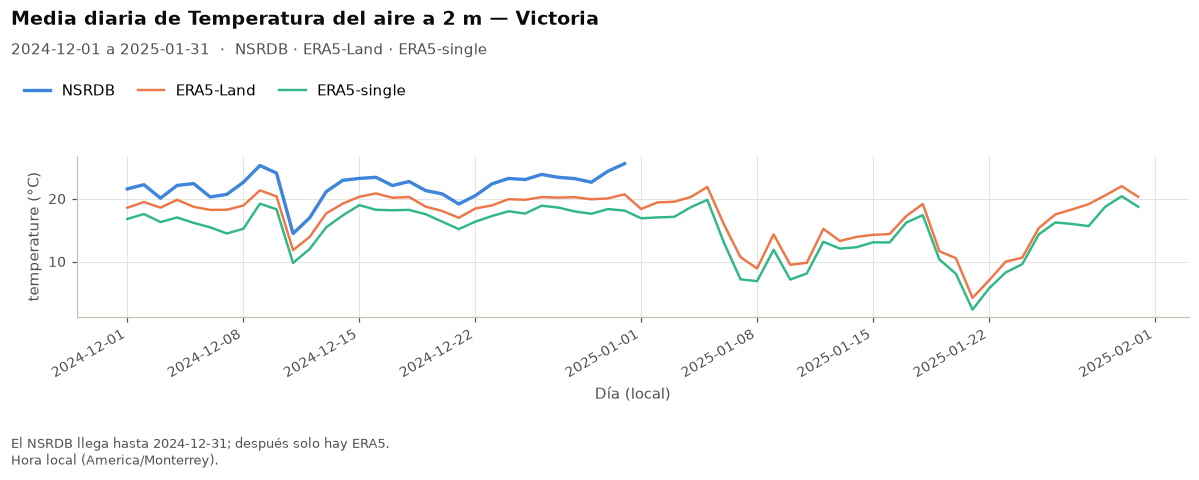

In [20]:
# A caballo entre los dos periodos: la línea del NSRDB se corta a fin de 2024
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    comparar_series("temperature", lugares="victoria", frecuencia="dia",
                    desde="2024-12-01", hasta="2025-01-31");

### El viento NO es comparable

ERA5 lo da a **10 m** y el NSRDB a **2 m**. El viento crece con la altura, así
que ERA5 sale sistemáticamente más alto: eso **no es error del reanálisis**, es
que no son la misma medida. La figura lo marca en el pie.

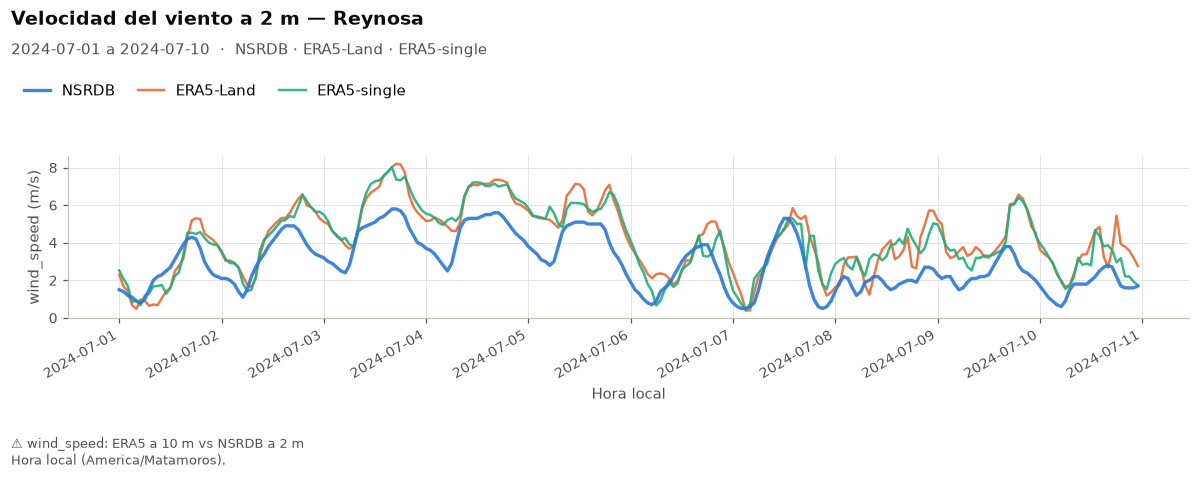

In [21]:
comparar_series("wind_speed", lugares="reynosa",
                desde="2024-07-01", hasta="2024-07-10");

Lo mismo aplica a `relative_humidity`, que ninguna de las dos fuentes mide: el
NSRDB la deriva de T2M+QV2M+PS y aquí sale de T2M+Td por Magnus-Tetens. Parte de
la diferencia es de fórmula, no de dato.

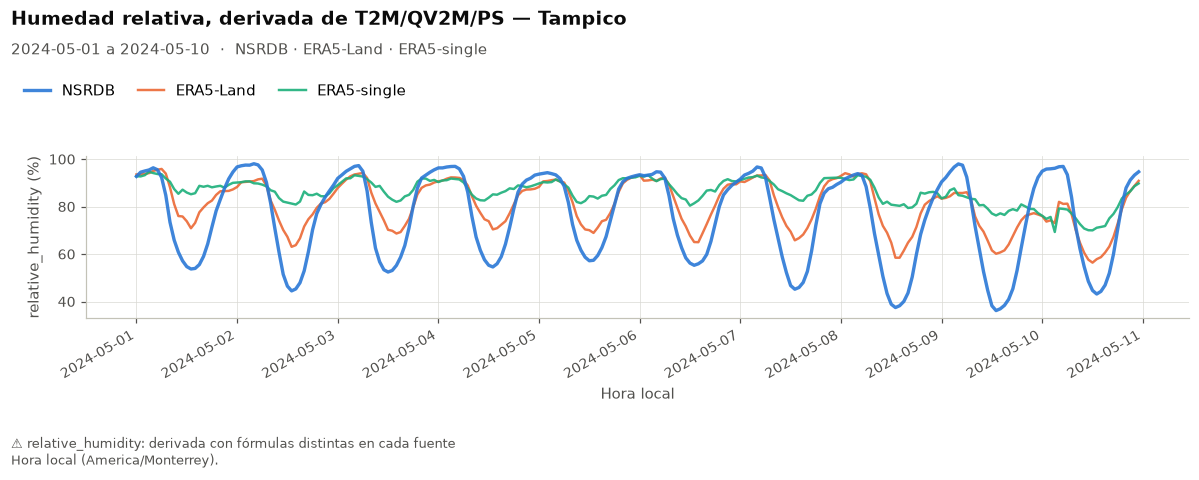

In [22]:
comparar_series("relative_humidity", lugares="tampico",
                desde="2024-05-01", hasta="2024-05-10");

### La dirección del viento es circular

Promediar 350° y 10° aritméticamente da 180° — el sur, cuando la respuesta es el
norte. Al agregar a día o mes se promedia como vector; el eje se fija a 0–360.

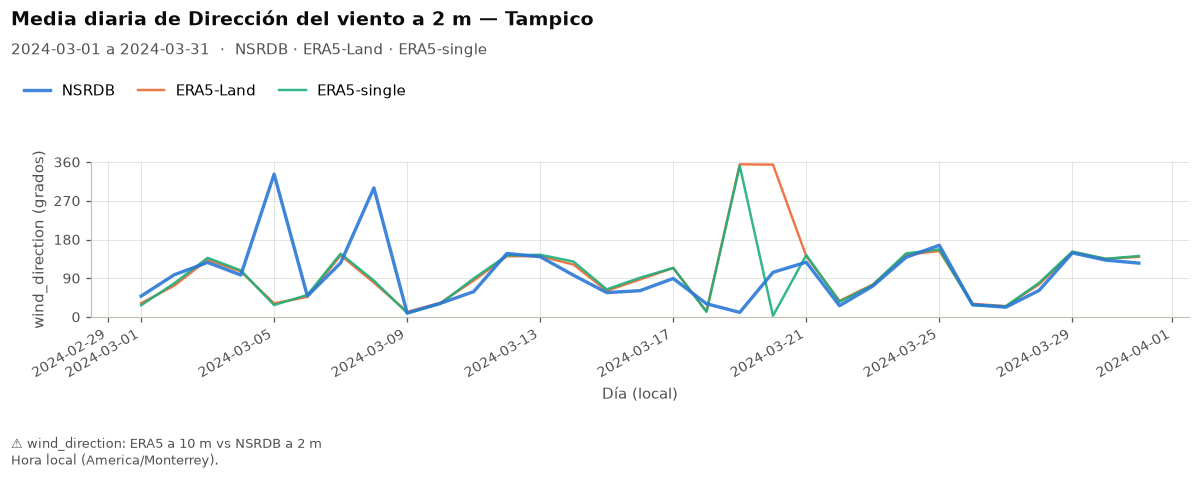

In [23]:
comparar_series("wind_direction", lugares="tampico",
                desde="2024-03-01", hasta="2024-03-31", frecuencia="dia");

## 11. Métricas, para acompañar la gráfica

La gráfica muestra la forma; `copernicus.comparar` pone el número. Se pueden
calcular sobre la misma tabla que ya se cargó.

In [24]:
import numpy as np

def metricas(d):
    """Sesgo, MAE, RMSE y correlación de cada ERA5 contra el NSRDB."""
    ancho = d.pivot_table(index=["nodo_id", "municipio", "datetime_utc"],
                          columns="fuente", values="valor")
    filas = []
    for f in [c for c in ancho.columns if c != "NSRDB"]:
        par = ancho[["NSRDB", f]].dropna()
        dif = par[f] - par["NSRDB"]
        filas.append({"fuente": f, "n": len(par),
                      "sesgo": dif.mean(), "mae": dif.abs().mean(),
                      "rmse": np.sqrt((dif ** 2).mean()),
                      "corr": par[f].corr(par["NSRDB"])})
    return pd.DataFrame(filas).round(3)

metricas(d)      # el GHI de 2024 en Victoria, Tampico y Reynosa

,fuente,n,sesgo,mae,rmse,corr
0,ERA5-Land,26334,-3.864,73.711,121.296,0.918
1,ERA5-single,26334,-3.262,73.868,121.487,0.918


In [25]:
# Por municipio: el sesgo no es el mismo en todas partes
pd.concat([metricas(g).assign(municipio=m)
           for m, g in d.groupby("municipio")], ignore_index=True)

,fuente,n,sesgo,mae,rmse,corr,municipio
0,ERA5-Land,8778,-5.918,73.084,120.006,0.917,Reynosa
1,ERA5-single,8778,-6.553,73.136,120.135,0.917,Reynosa
2,ERA5-Land,8778,-6.592,74.715,122.754,0.914,Tampico
3,ERA5-single,8778,-5.251,74.308,122.027,0.915,Tampico
4,ERA5-Land,8778,0.918,73.335,121.113,0.925,Victoria
5,ERA5-single,8778,2.018,74.159,122.289,0.923,Victoria


## 12. Cada fuente etiqueta la hora en un extremo distinto del intervalo

Algo que la gráfica deja ver y conviene medir antes de sacar conclusiones: las
curvas de ERA5 van sistemáticamente **una hora por detrás** de las del NSRDB. Se
nota en el flanco de subida del GHI.

No tiene que ver con husos ni con el horario de verano: **las dos series están en
UTC**. Es dónde pone cada una la etiqueta del intervalo horario.

- **NSRDB** etiqueta con el **inicio**: el valor `12:00` es el promedio de
  12:00–13:00.
- **ERA5** acumula `ssrd` sobre la **hora anterior** y etiqueta con el **final**:
  el valor `13:00` es lo acumulado entre 12:00 y 13:00.

El mismo intervalo físico lleva dos etiquetas distintas. La forma de comprobarlo
es correlacionar con la serie desplazada: si el máximo no cae en el desfase 0,
las dos fuentes no están alineadas.

In [26]:
# Perfil diurno medio de junio 2024 en Victoria, en UTC.
# Se lee directamente: ERA5 en la hora `t` es el NSRDB de la hora `t-1`.
d_jun = cargar("ghi", lugares="victoria", desde="2024-06-01", hasta="2024-06-30")
(d_jun.groupby(["fuente", d_jun.datetime_utc.dt.hour])["valor"]
      .mean().unstack(0).loc[11:17].round(1)
      .rename_axis("hora UTC"))

fuente,ERA5-Land,ERA5-single,NSRDB
hora UTC,,,
11,0.0,0.0,0.0
12,0.4,0.3,66.4
13,65.2,64.0,227.6
14,225.5,223.4,395.1
15,403.2,402.3,540.9
16,562.4,561.5,681.0
17,698.9,697.0,774.9


Que el NSRDB etiqueta el **inicio** del intervalo se confirma con un reloj
independiente del propio dato: en Victoria (lon −99.14°) el mediodía solar cae a
las **18.6 UTC**, y el mínimo de `solar_zenith_angle` está etiquetado a las
**18 UTC** — el centro real de ese intervalo, 18:30.

De paso, eso prueba que el parquet está en UTC: en hora local estándar el mínimo
caería cerca de las 12.

In [27]:
import numpy as np

def correlacion_por_desfase(variable, lugar, desfases=(-2, -1, 0, 1, 2)):
    """Correlación NSRDB vs ERA5 desplazando ERA5 en horas."""
    d = cargar(variable, lugares=lugar, desde="2024-01-01", hasta="2024-12-31")
    a = d.pivot_table(index="datetime_utc", columns="fuente", values="valor").dropna()
    return pd.DataFrame(
        {f: {k: round(a["NSRDB"].corr(a[f].shift(k)), 4) for k in desfases}
         for f in ("ERA5-Land", "ERA5-single")}).rename_axis("desfase (h)")

correlacion_por_desfase("ghi", "Victoria")

,ERA5-Land,ERA5-single
desfase (h),,
-2,0.9145,0.9157
-1,0.9706,0.9708
0,0.9245,0.9233
1,0.7861,0.7836
2,0.5813,0.5782


El máximo está en **−1**, no en 0: el valor que ERA5 etiqueta a las `t` se
corresponde con el que el NSRDB etiqueta a las `t−1`, tal como predice el
etiquetado inicio-vs-final del intervalo.

Cuánto cambia esto las métricas:

In [28]:
def rmse_por_desfase(variable, lugar="Victoria"):
    d = cargar(variable, lugares=lugar, desde="2024-01-01", hasta="2024-12-31")
    a = d.pivot_table(index="datetime_utc", columns="fuente", values="valor").dropna()
    filas = []
    for k in (0, -1):
        par = a[["NSRDB"]].assign(era5=a["ERA5-Land"].shift(k)).dropna()
        dif = par["era5"] - par["NSRDB"]
        filas.append({"variable": variable, "desfase": k,
                      "rmse": round(np.sqrt((dif ** 2).mean()), 3),
                      "corr": round(par["era5"].corr(par["NSRDB"]), 4)})
    return pd.DataFrame(filas)

pd.concat([rmse_por_desfase(v) for v in ("ghi", "temperature", "pressure")],
          ignore_index=True)

,variable,desfase,rmse,corr
0,ghi,0,121.113,0.9245
1,ghi,-1,75.707,0.9706
2,temperature,0,3.930,0.9072
3,temperature,-1,3.373,0.9564
4,pressure,0,25.618,0.9774
5,pressure,-1,25.610,0.9874


**El RMSE del GHI cae de 121 a 76 W/m² (−37 %) solo por reetiquetar la hora.**

### Ojo: las variables instantáneas son otro caso

El desfase de una hora **exacto** es el del GHI, y viene de la acumulación. Para
`t2m`, `sp`, `u10` y `v10` ERA5 da valores **instantáneos en `t`**, no
acumulados: frente al NSRDB —media de `[t, t+1)`, centrada en `t+30min`— el
desajuste real es de **media hora**, y con datos horarios no se puede resolver
medio paso. Por eso en temperatura `−1` sale mejor que `0` (3.93 → 3.37 °C) pero
**ninguno de los dos es exacto**. En presión casi da igual: es una variable suave
que media hora apenas mueve.

Para GHI, reetiquetar es una corrección; para las instantáneas es una
aproximación que hay que elegir y documentar, no mezclar entre análisis.

### Consecuencia práctica

**Las métricas calculadas sin alinear sobrestiman la discrepancia entre
fuentes**, sobre todo en las variables de ciclo diario marcado. Los datos se
dejan tal como los entrega cada fuente —corregirlos por dentro escondería el
problema— así que el desplazamiento se aplica explícitamente al comparar, como
arriba. Conviene pensarlo como "restar una hora a la marca de tiempo de ERA5" y
no como un `shift` con signo, que es donde uno se equivoca.

## 13. Guardar

`guardar=` escribe el PNG (crea la carpeta si hace falta) y devuelve la figura.

[fig] ../../Results/comparacion/ghi_victoria_jun2024.png


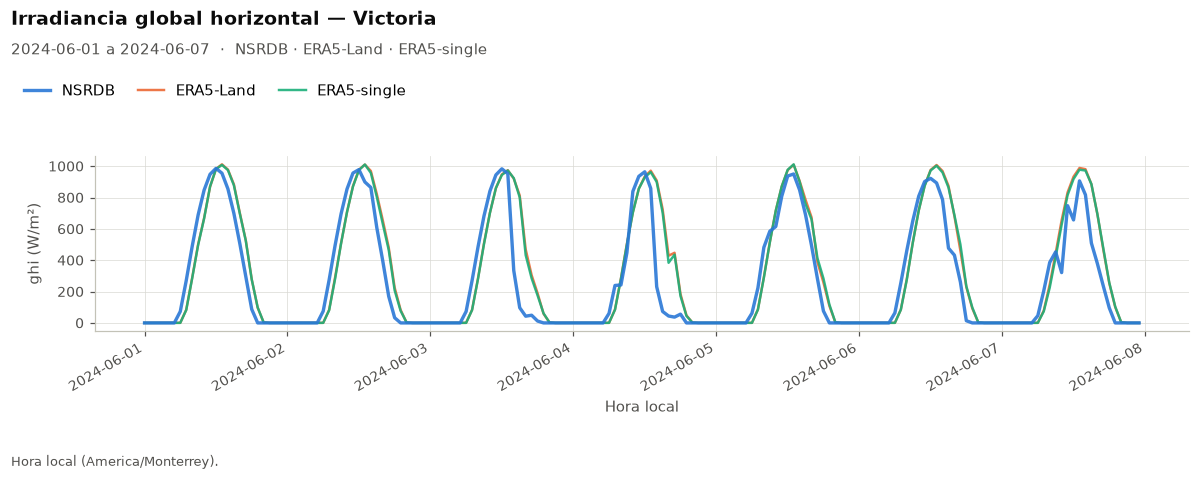

In [29]:
fig = comparar_series("ghi", lugares="victoria", desde="2024-06-01",
                      hasta="2024-06-07",
                      guardar="../../Results/comparacion/ghi_victoria_jun2024.png")

---

## Resumen de parámetros

| parámetro | qué hace | por omisión |
|---|---|---|
| `variable` | qué se compara | `"ghi"` |
| `lugares` | `nodo_id`, municipio, o lista | los 43 |
| `desde` / `hasta` | rango inclusivo, hora local | sin límite |
| `horas` | `(ini, fin)` o lista de horas | todas |
| `meses` | lista de meses | todos |
| `fuentes` | subconjunto de las tres | las tres |
| `frecuencia` | `"hora"`, `"dia"`, `"mes"` | `"hora"` |
| `agregacion` | `"media"`, `"max"`, `"min"`, `"suma"` | `"media"` |
| `tz` | `"local"` o `"utc"` | `"local"` |
| `facetas` | `"auto"`, `True`, `False` | `"auto"` |
| `titulo`, `subtitulo`, `etiqueta_x`, `etiqueta_y`, `nota` | textos; `""` los quita | autogenerados |
| `leyenda` | mostrarla | `True` |
| `figsize`, `ax`, `guardar` | lienzo y salida | — |
| `datos` | tabla ya cargada con `cargar()` | — |
| `mostrar_tabla` | devolver también los datos dibujados | `False` |